In [181]:
from math import isinf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import persim
from skfda.representation.grid import FDataGrid
from skfda.preprocessing.dim_reduction.feature_extraction import FPCA
from lifelines import CoxPHFitter
import collections
from Project1.A1.gudhi_persistence import persim_diagram


C:\Users\sranasin\AppData\Local\Temp\ipykernel_4464\1296274595.py:8: DeprecationWarning: The module "feature_extraction" is deprecated.Please use "dim_reduction" for FPCAor "feature_construction" for feature construction techniques
  from skfda.preprocessing.dim_reduction.feature_extraction import FPCA


In [ ]:
#### Contaigion Map for i-nodes, j-realizations

J = 2 # ALl combination of seeding sites
N = 10 # number of ndoes
T = 3 # Max Time/Filatration Steps
dim = 2

betti_curves = [{0: {0: 2, 1: 0, 2: 0}, 1: {0: 1, 1: 4, 2: 0}, 2: {0: 1, 1: 10, 2: 0}},
                {0: {0: 2, 1: 0, 2: 0}, 1: {0: 1, 1: 4, 2: 0}, 2: {0: 1, 1: 10, 2: 0}}]
activation_times = [np.array([1., 0., 0., 1., 1., 2., 2., 2., 1., 1.]).astype(int),
                    np.array([1., 0., 0., 1., 1., 2., 2., 2., 1., 1.]).astype(int)]


In [ ]:
#######------- Create grid for landscaspe
rows = []
for j in range(J):
    grid = np.arange(T)
    betti_fdata = FDataGrid(data_matrix=betti_curves[j], grid_points=grid)

    ### --- We need functional PC's
    fpca = FPCA(n_components=3)
    scores = fpca.fit_transform(betti_fdata)[None, :]

    for i in range(N):
        rows.append({
            'T': activation_times[j, i],
            'E': 1,
            'cluster': j,
            **{f'FPCA{k+1}': scores[0, k] for k in range(scores.shape[1])}
        })

df = pd.DataFrame(rows)


In [6]:
import importlib, os
import numpy as np, networkx as nx, gudhi as gd
from IPython.display import display

import gudhi_persistence as gp
import utilsA1 as utils
import test_WTM as wtm
from persim import PersLandscapeApprox

importlib.reload(wtm)
importlib.reload(utils)
importlib.reload(gp)


<module 'gudhi_persistence' from 'C:\\Users\\sranasin\\Desktop\\NetworkModels\\Project1\\A1\\gudhi_persistence.py'>

In [8]:

params_temp_list = {'num_nodes': 60, 'num_neighbor_nodes': 1,
                    'total_random_edges': 3, 'distance_threshold': 2, 'weighted': False,
                    'ngeo_placement': 'ngeo_per_node', 'n_seeds': 2, 'node_active_threshold': 0.01,
                    'upper_weight_limit': 5, 'skew_power': 3, 'seed_cluster_distance': 10,
                    'ngeom_edges_in_persistence': False, 'max_persistence_dim': 2,
                    'seeding_method': 'cluster_seeding'}

params_temp_list['threshold_sum']= sum(range(params_temp_list['num_nodes'])) - 1

G, seed_nodes = wtm.simulate_contagion_map(params=params_temp_list)
graph, snapshots, activation_times, results = wtm.simulate_contagion_realization(graph = G, init_seeds = seed_nodes, params = params_temp_list,
max_steps = 100, sim_id = 1, realization_id = 1)

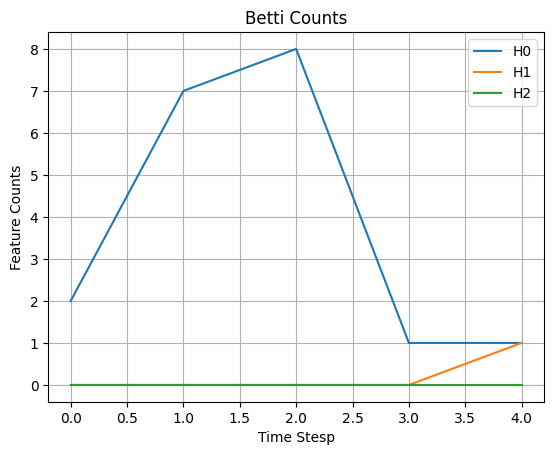

In [207]:

betti_numbers, simplex_intervals = gp.compute_persistence(graph=graph, activation_times=activation_times, max_dim=2)
gp.betti_nums_over_time(betti_over_time=betti_numbers)

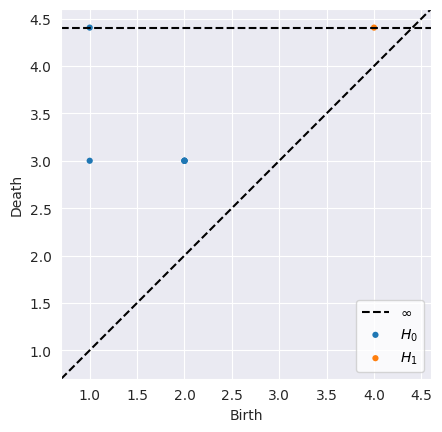

In [10]:
gp.persim_diagram(simplex_intervals=simplex_intervals)

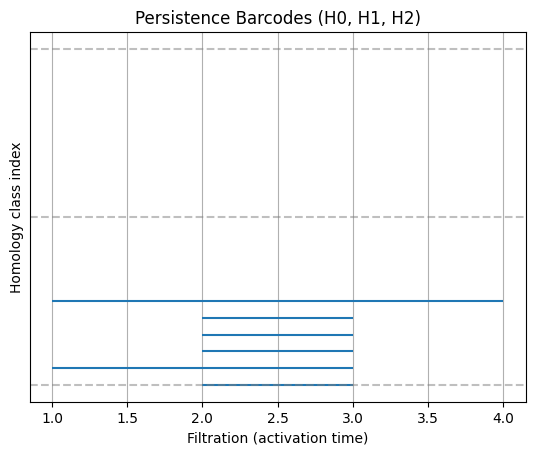

In [11]:
gp.plot_persistence_barcodes(simplex_intervals, activation_times, max_dim=2)

In [161]:
simplex_intervals[0][:][-1]

(4, [(2.0, 3.0), (1.0, 3.0), (2.0, 3.0), (2.0, 3.0), (2.0, 3.0), (1.0, inf)])

In [99]:
import persim

In [117]:
birth_death_simplex_intervals = dict()
for dim in range(2):
    birth_death_simplex_intervals[dim] = simplex_intervals[dim][-1][1]


H0_diag = npbirth_death_simplex_intervals[0]
H1_diag = np.array([(4, np.inf)])
# H2_diag = np.array(birth_death_simplex_intervals[2])

In [118]:
# birth_death_simplex_intervals[0]
# death_cap = 2 * np.max(np.isfinite(H0_diag[:, 1]) * H0_diag[:, 1])  # or just some large number like 10
H0_diag[~np.isfinite(H0_diag[:, 1]), 1] = 10
H1_diag[~np.isfinite(H1_diag[:, 1]), 1] = 10
#
#
# H0_diag = np.array(H0_diag, dtype=float)
# H1_diag = np.array(H1_diag, dtype=float)

TypeError: list indices must be integers or slices, not tuple

In [120]:
simplex_intervals[0][-1][1]

[(2.0, 3.0), (1.0, 3.0), (2.0, 3.0), (2.0, 3.0), (2.0, 3.0), (1.0, inf)]

In [107]:
# H0_vec = persim.PersistenceLandscaper(hom_deg=0, num_steps = 5, flatten = True).fit_transform([H0_diag])[0]
# H2_vec = persim.PersistenceLandscaper(hom_deg=2, num_steps = 100, flatten = True).fit_transform([H2_diag])[0]

In [124]:
H0_diag = np.array([(2.0, 3.0), (1.0, 3.0), (2.0, 3.0), (2.0, 3.0), (2.0, 3.0), (1.0, 10)])

pl = persim.PersistenceLandscaper(hom_deg = 0, start = 0, stop = 3,  num_steps = 10, flatten = True)
pl.fit([H0_diag])
H0_vec = pl.transform([H0_diag])[0]

In [129]:
H1_diag = [np.array([[4, 10]])]
pl = persim.PersistenceLandscaper(hom_deg = 1, num_steps = 10, flatten = True)
pl.fit(H1_diag)
H1_vec = pl.transform([H1_diag])

IndexError: list index out of range

In [157]:
max(simplex_intervals.keys())

2

In [131]:

def prepare_persim_diagrams(diag_dict, inf_replacement=10.0):
    result = []
    for hom_deg in sorted(diag_dict.keys()):
        all_pairs = []
        for _, pairs in diag_dict[hom_deg]:
            for birth, death in pairs:
                birth = float(birth)
                death = float('inf') if death == float('inf') else float(death)
                if np.isinf(death):
                    death = inf_replacement
                all_pairs.append((birth, death))
        result.append(np.array(all_pairs).reshape(-1, 2))
    return result


diagrams = prepare_persim_diagrams(simplex_intervals)

In [132]:
diagrams

[array([[ 0., 10.],
        [ 0., 10.],
        [ 1., 10.],
        [ 1., 10.],
        [ 1., 10.],
        [ 1., 10.],
        [ 1., 10.],
        [ 1., 10.],
        [ 1., 10.],
        [ 1., 10.],
        [ 1., 10.],
        [ 2., 10.],
        [ 2., 10.],
        [ 2., 10.],
        [ 2., 10.],
        [ 2., 10.],
        [ 2., 10.],
        [ 2.,  3.],
        [ 1.,  3.],
        [ 2.,  3.],
        [ 2.,  3.],
        [ 2.,  3.],
        [ 1., 10.],
        [ 2.,  3.],
        [ 1.,  3.],
        [ 2.,  3.],
        [ 2.,  3.],
        [ 2.,  3.],
        [ 1., 10.]]),
 array([[ 4., 10.]]),
 array([], shape=(0, 2), dtype=float64)]

In [152]:
pl = persim.PersistenceLandscaper(hom_deg = 0, num_steps = 10, flatten = True)
pl.fit(diagrams)
vec0 = pl.transform(diagrams)
print(vec0)

[0.         1.11111111 2.22222222 3.33333333 4.44444444 4.44444444
 3.33333333 2.22222222 1.11111111 0.         0.         1.11111111
 2.22222222 3.33333333 4.44444444 4.44444444 3.33333333 2.22222222
 1.11111111 0.         0.         0.         1.11111111 2.22222222
 3.33333333 4.44444444 3.33333333 2.22222222 1.11111111 0.
 0.         0.         1.11111111 2.22222222 3.33333333 4.44444444
 3.33333333 2.22222222 1.11111111 0.         0.         0.
 1.11111111 2.22222222 3.33333333 4.44444444 3.33333333 2.22222222
 1.11111111 0.         0.         0.         1.11111111 2.22222222
 3.33333333 4.44444444 3.33333333 2.22222222 1.11111111 0.
 0.         0.         1.11111111 2.22222222 3.33333333 4.44444444
 3.33333333 2.22222222 1.11111111 0.         0.         0.
 1.11111111 2.22222222 3.33333333 4.44444444 3.33333333 2.22222222
 1.11111111 0.         0.         0.         1.11111111 2.22222222
 3.33333333 4.44444444 3.33333333 2.22222222 1.11111111 0.
 0.         0.         1.11111111 2

In [151]:
pl1 = persim.PersistenceLandscaper(hom_deg = 1, num_steps = 10, flatten = False)
pl1.fit(diagrams)
vec1 = pl1.transform(diagrams)
print(vec1)

[[0.         0.66666667 1.33333333 2.         2.66666667 2.66666667
  2.         1.33333333 0.66666667 0.        ]]


In [138]:
H1_vec

np.float64(0.6666666666666666)

In [221]:
importlib.reload(gp)


landscape_matrix_dict = gp.persistence_landscapes(simplex_intervals=simplex_intervals,
                          num_steps = 10, inf_replacement = 10.0,
                          flatten = False
                          )

t: 0, hom_deg: 0, and diagram: [array([[ 0., 10.],
       [ 0., 10.]])]
t: 0, hom_deg: 0, and diagram: [array([[ 0., 10.],
       [ 0., 10.]])]
t: 0, hom_deg: 0, and diagram: [array([[ 0., 10.],
       [ 0., 10.]])]
t: 1, hom_deg: 0, and diagram: [array([[ 1., 10.],
       [ 1., 10.],
       [ 1., 10.],
       [ 1., 10.],
       [ 1., 10.],
       [ 1., 10.],
       [ 1., 10.]])]
t: 1, hom_deg: 0, and diagram: [array([[ 1., 10.],
       [ 1., 10.],
       [ 1., 10.],
       [ 1., 10.],
       [ 1., 10.],
       [ 1., 10.],
       [ 1., 10.]])]
t: 1, hom_deg: 0, and diagram: [array([[ 1., 10.],
       [ 1., 10.],
       [ 1., 10.],
       [ 1., 10.],
       [ 1., 10.],
       [ 1., 10.],
       [ 1., 10.]])]
t: 2, hom_deg: 0, and diagram: [array([[ 1., 10.],
       [ 1., 10.],
       [ 2., 10.],
       [ 2., 10.],
       [ 2., 10.],
       [ 2., 10.],
       [ 2., 10.],
       [ 2., 10.]])]
t: 2, hom_deg: 0, and diagram: [array([[ 1., 10.],
       [ 1., 10.],
       [ 2., 10.],
       [

In [222]:
landscape_matrix_dict

{0: {0: array([0.        , 1.11111111, 2.22222222, 3.33333333, 4.44444444,
         4.44444444, 3.33333333, 2.22222222, 1.11111111, 0.        ])},
 1: {0: array([0., 1., 2., 3., 4., 4., 3., 2., 1., 0.])},
 2: {0: array([0.  , 0.25, 1.25, 2.25, 3.25, 4.  , 3.  , 2.  , 1.  , 0.  ])},
 3: {0: array([0. , 1. , 1. , 1.5, 2. , 2. , 1.5, 1. , 0.5, 0. ])},
 4: {0: array([0. , 1. , 1. , 1.5, 2. , 2. , 1.5, 1. , 0.5, 0. ])}}